Fetching data for 20 countries...
  [1/20] Fetching China...
  [2/20] Fetching United States...
  [3/20] Fetching Japan...
  [4/20] Fetching Germany...
  [5/20] Fetching United Kingdom...
  [6/20] Fetching France...
  [7/20] Fetching Italy...
  [8/20] Fetching Canada...
  [9/20] Fetching South Korea...
  [10/20] Fetching Australia...
  [11/20] Fetching India...
  [12/20] Fetching Brazil...
  [13/20] Fetching Mexico...
  [14/20] Fetching Turkey...
  [15/20] Fetching Indonesia...
  [16/20] Fetching Saudi Arabia...
  [17/20] Fetching South Africa...
  [18/20] Fetching Argentina...
  [19/20] Fetching Egypt...
  [20/20] Fetching Netherlands...


C:\Users\j2063\AppData\Local\Temp\ipykernel_15524\4135781470.py:26: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.




✅ Data fetched successfully! Shape: (500, 7)
   Columns: ['year', 'GDP Growth (%)', 'Inflation (%)', 'Unemployment Rate (%)', 'Trade (% of GDP)', 'Government Debt (% of GDP)', 'country']
✅ Data saved to macro_data.csv

📊 Data Preview:
   year  GDP Growth (%)  Inflation (%)  Unemployment Rate (%)  \
0  2024        4.977357       0.218129                   4.59   
1  2023        5.414843       0.234837                   4.67   
2  2022        3.134189       1.973576                   4.98   
3  2021        8.570085       0.981015                   4.55   
4  2020        2.340188       2.419422                   5.00   

   Trade (% of GDP)  Government Debt (% of GDP) country  
0         37.198420                         NaN   China  
1         36.105192                         NaN   China  
2         37.440720                         NaN   China  
3         36.520691                         NaN   China  
4         34.038951                         NaN   China  

📊 Data Info:
<class 'wbd

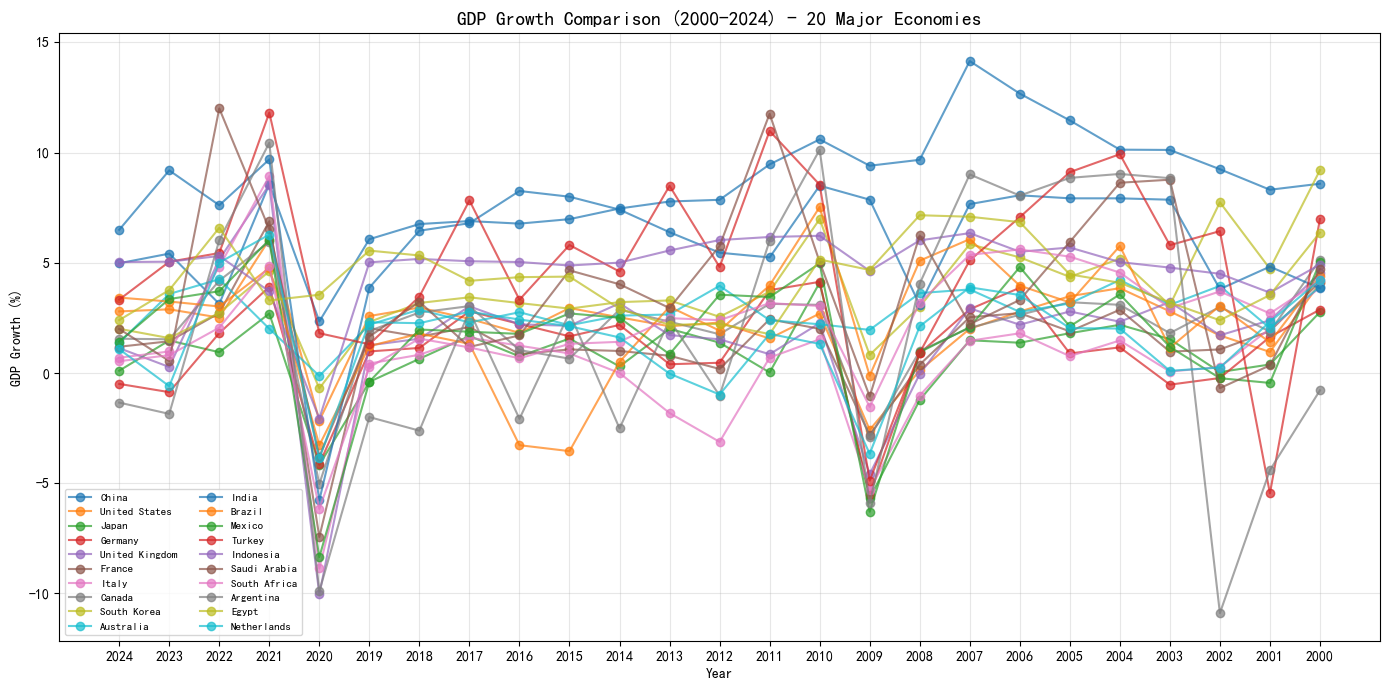

✅ GDP chart saved: gdp_comparison.png


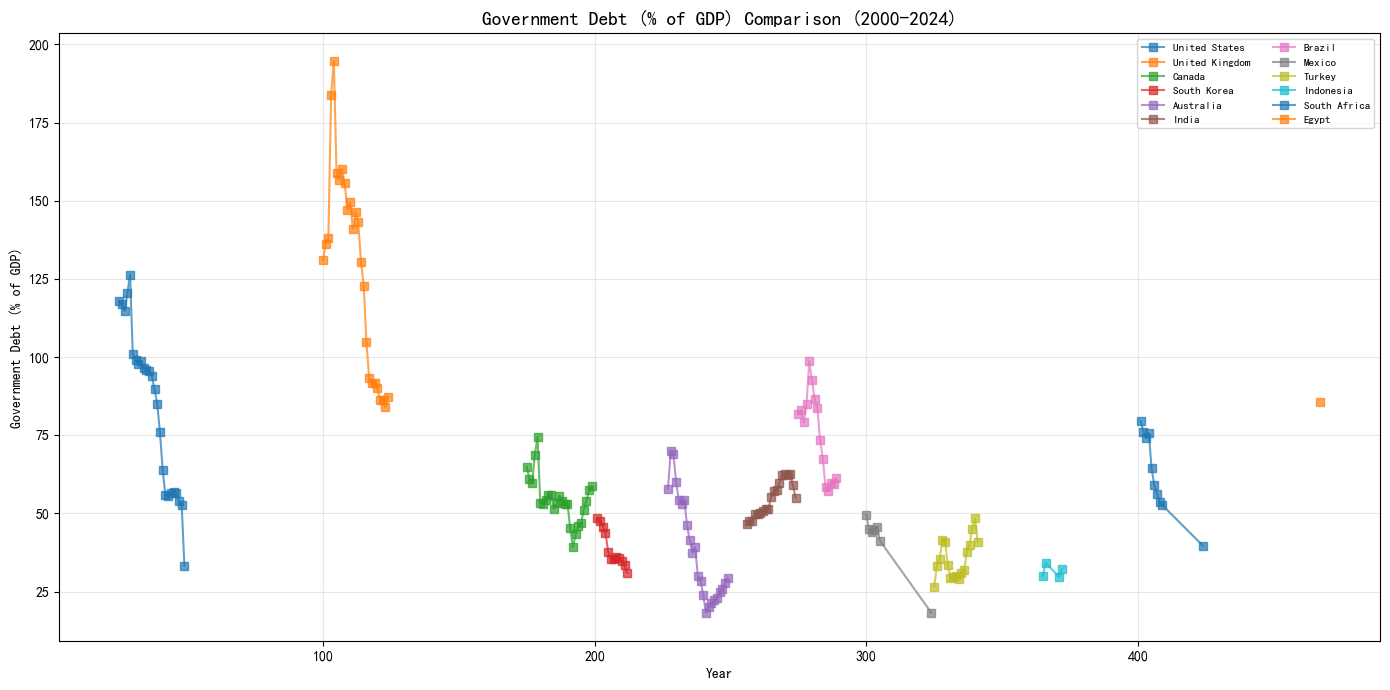

✅ Debt chart saved: debt_comparison.png


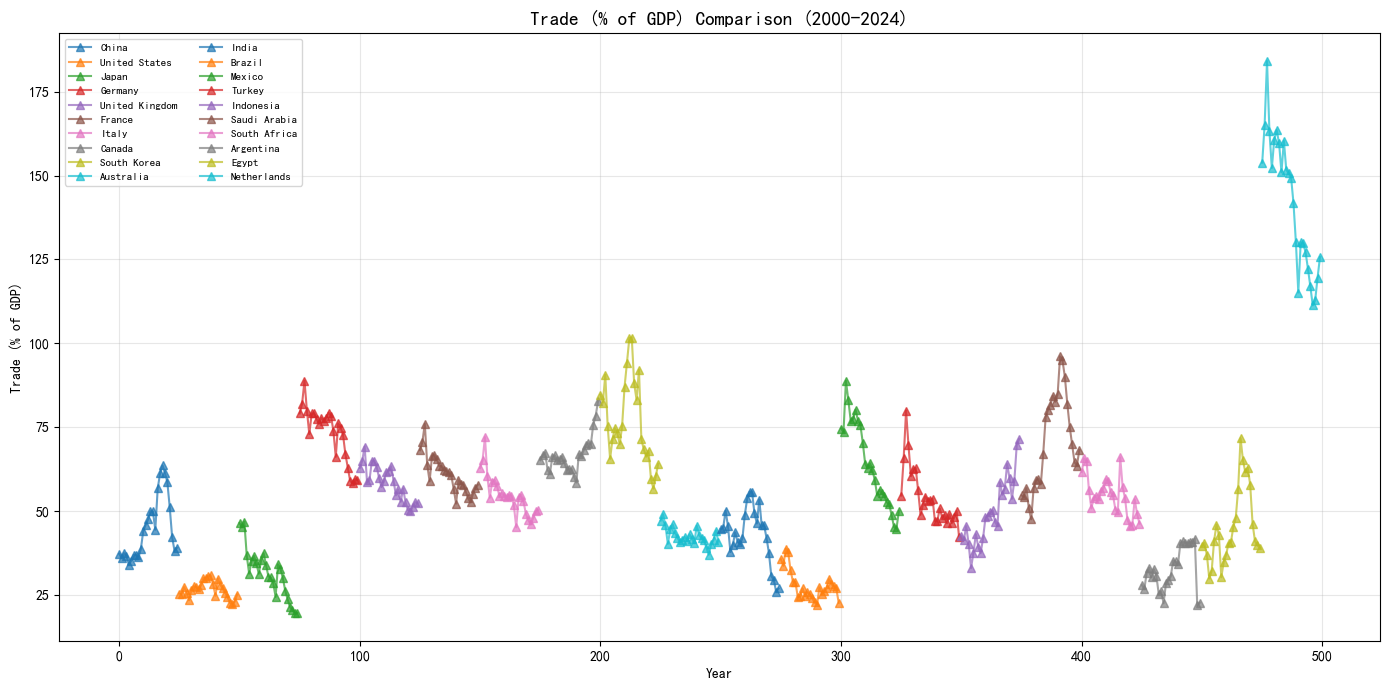

✅ Trade chart saved: trade_comparison.png


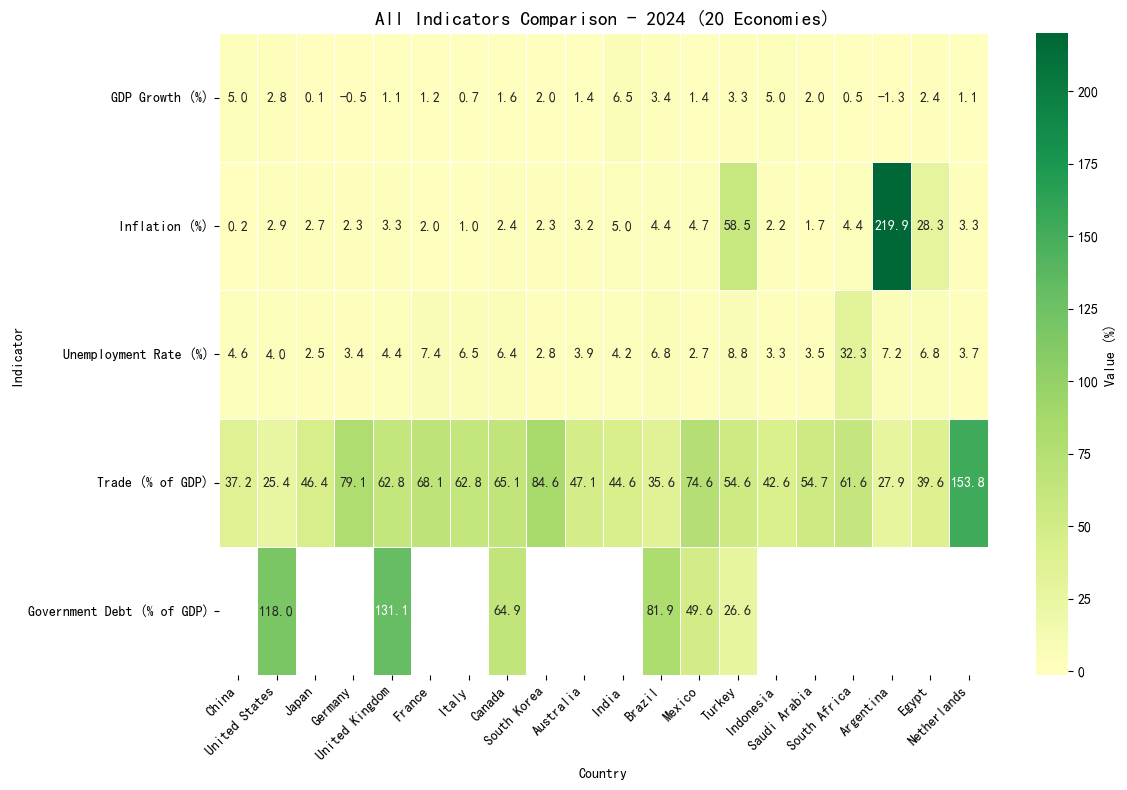

✅ Heatmap saved: heatmap_comparison.png

📌 KEY FINDINGS SUMMARY (20 Major Economies)

📈 Top 5 Economies by Average GDP Growth:
   1. China: 8.19%
   2. India: 6.26%
   3. Turkey: 5.10%
   4. Indonesia: 4.89%
   5. Egypt: 4.30%

🌍 Top 5 Most Open Economies (Highest Trade % of GDP):
   1. Netherlands: 141.9%
   2. South Korea: 77.0%
   3. Germany: 73.4%
   4. Saudi Arabia: 70.4%
   5. Canada: 66.8%

⚠️ Top 5 Highest Government Debt (Risk Indicator):
   1. United Kingdom: 128.5%
   2. Egypt: 85.8%
   3. United States: 84.5%
   4. Brazil: 75.2%
   5. South Africa: 63.1%

✅ Notebook completed!


In [13]:
# 5. 分批次获取数据（避免超时）
print(f"Fetching data for {len(countries)} countries...")

all_data = []
for i, country in enumerate(countries):
    print(f"  [{i+1}/{len(countries)}] Fetching {country_names[country]}...")
    try:
        data = wbdata.get_dataframe(
            indicators_dict, 
            country=country, 
            date=(start_date, end_date)
        )
        # 重置索引，添加国家列
        data = data.reset_index()
        data['country'] = country_names[country]  # 直接使用国家名称
        # 重命名日期列
        data = data.rename(columns={'date': 'year'})
        all_data.append(data)
        time.sleep(0.5)
    except Exception as e:
        print(f"    ⚠️ Error for {country}: {e}")
        continue

# 6. 合并数据
if all_data:
    data_clean = pd.concat(all_data, ignore_index=True)
    print(f"\n✅ Data fetched successfully! Shape: {data_clean.shape}")
    print(f"   Columns: {data_clean.columns.tolist()}")
else:
    print("❌ No data fetched!")
    data_clean = pd.DataFrame()

# 7. 保存 CSV
data_clean.to_csv('macro_data.csv', index=False)
print("✅ Data saved to macro_data.csv")

# 8. 显示预览
print("\n📊 Data Preview:")
print(data_clean.head())

print("\n📊 Data Info:")
print(data_clean.info())

# 9. 生成图表
if not data_clean.empty:
    # ===== GDP增长趋势图 =====
    plt.figure(figsize=(14, 7))
    
    # 获取所有国家
    all_countries = data_clean['country'].unique()
    
    for country in all_countries:
        country_data = data_clean[data_clean['country'] == country]
        if not country_data.empty:
            plt.plot(country_data['year'], country_data['GDP Growth (%)'], 
                    marker='o', linewidth=1.5, alpha=0.7, label=country)
    
    plt.title('GDP Growth Comparison (2000-2024) - 20 Major Economies', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('GDP Growth (%)')
    plt.legend(loc='best', ncol=2, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('gdp_comparison.png', dpi=150)
    plt.show()
    print("✅ GDP chart saved: gdp_comparison.png")

    # ===== 政府债务趋势图 =====
    plt.figure(figsize=(14, 7))
    
    for country in all_countries:
        country_data = data_clean[data_clean['country'] == country]
        if not country_data.empty:
            # 只绘制有债务数据的国家
            debt_series = country_data['Government Debt (% of GDP)'].dropna()
            if not debt_series.empty:
                plt.plot(debt_series.index, debt_series.values, 
                        marker='s', linewidth=1.5, alpha=0.7, label=country)
    
    plt.title('Government Debt (% of GDP) Comparison (2000-2024)', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('Government Debt (% of GDP)')
    plt.legend(loc='best', ncol=2, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('debt_comparison.png', dpi=150)
    plt.show()
    print("✅ Debt chart saved: debt_comparison.png")

    # ===== 贸易开放度趋势图 =====
    plt.figure(figsize=(14, 7))
    
    for country in all_countries:
        country_data = data_clean[data_clean['country'] == country]
        if not country_data.empty:
            trade_series = country_data['Trade (% of GDP)'].dropna()
            if not trade_series.empty:
                plt.plot(trade_series.index, trade_series.values, 
                        marker='^', linewidth=1.5, alpha=0.7, label=country)
    
    plt.title('Trade (% of GDP) Comparison (2000-2024)', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('Trade (% of GDP)')
    plt.legend(loc='best', ncol=2, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('trade_comparison.png', dpi=150)
    plt.show()
    print("✅ Trade chart saved: trade_comparison.png")

    # ===== 热力图：最新年份数据 =====
    latest_year = data_clean['year'].max()
    latest_data = data_clean[data_clean['year'] == latest_year].copy()
    
    if not latest_data.empty:
        # 选择数值列
        numeric_cols = ['GDP Growth (%)', 'Inflation (%)', 'Unemployment Rate (%)', 
                       'Trade (% of GDP)', 'Government Debt (% of GDP)']
        
        heatmap_data = latest_data.set_index('country')[numeric_cols]
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(heatmap_data.T, annot=True, cmap='RdYlGn', center=0, 
                    fmt='.1f', linewidths=0.5, cbar_kws={'label': 'Value (%)'})
        plt.title(f'All Indicators Comparison - {latest_year} (20 Economies)', fontsize=14)
        plt.xlabel('Country')
        plt.ylabel('Indicator')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('heatmap_comparison.png', dpi=150)
        plt.show()
        print("✅ Heatmap saved: heatmap_comparison.png")

    # ===== 关键发现 =====
    print("\n" + "="*60)
    print("📌 KEY FINDINGS SUMMARY (20 Major Economies)")
    print("="*60)
    
    # 平均GDP增长
    avg_gdp = data_clean.groupby('country')['GDP Growth (%)'].mean().sort_values(ascending=False)
    print(f"\n📈 Top 5 Economies by Average GDP Growth:")
    for i, (country, val) in enumerate(avg_gdp.head(5).items(), 1):
        print(f"   {i}. {country}: {val:.2f}%")
    
    # 贸易开放度
    avg_trade = data_clean.groupby('country')['Trade (% of GDP)'].mean().sort_values(ascending=False)
    print(f"\n🌍 Top 5 Most Open Economies (Highest Trade % of GDP):")
    for i, (country, val) in enumerate(avg_trade.head(5).items(), 1):
        print(f"   {i}. {country}: {val:.1f}%")
    
    # 政府债务（只计算有数据的国家）
    debt_data = data_clean['Government Debt (% of GDP)'].dropna()
    if not debt_data.empty:
        avg_debt = data_clean.groupby('country')['Government Debt (% of GDP)'].mean().sort_values(ascending=False)
        print(f"\n⚠️ Top 5 Highest Government Debt (Risk Indicator):")
        for i, (country, val) in enumerate(avg_debt.head(5).items(), 1):
            print(f"   {i}. {country}: {val:.1f}%")

print("\n✅ Notebook completed!")

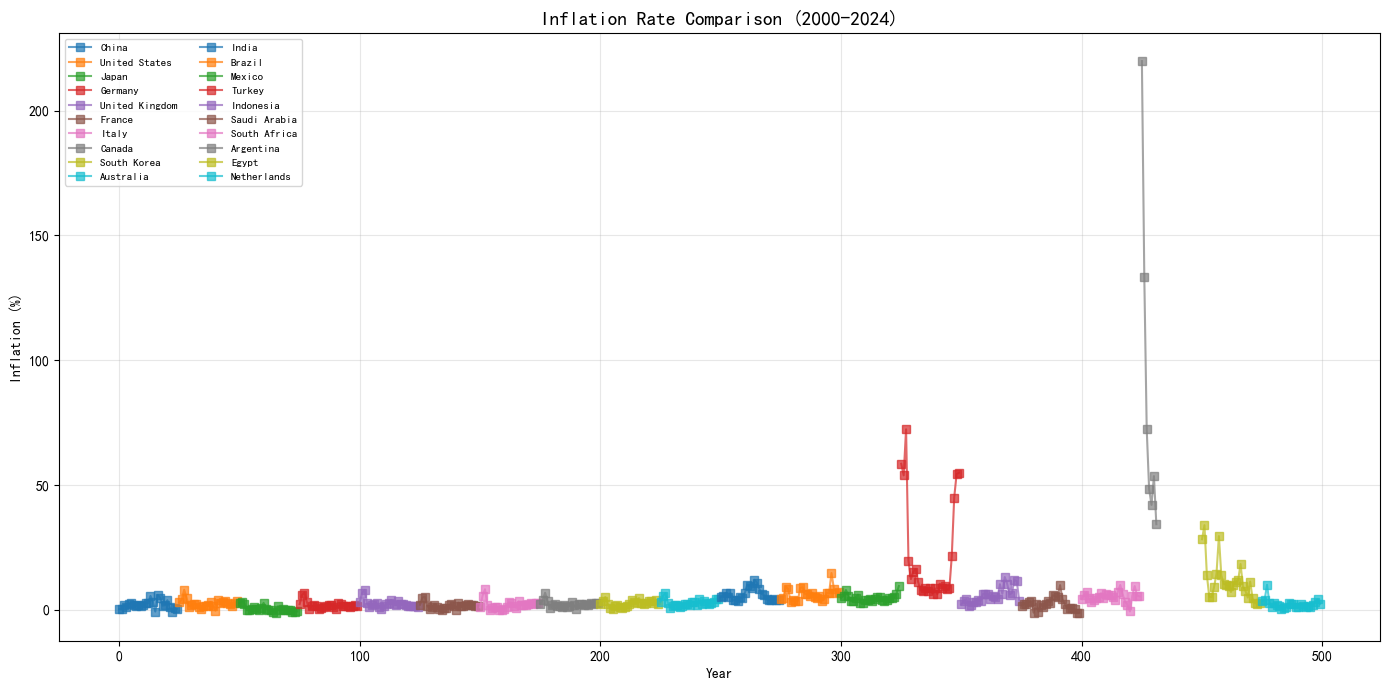

✅ Inflation chart saved


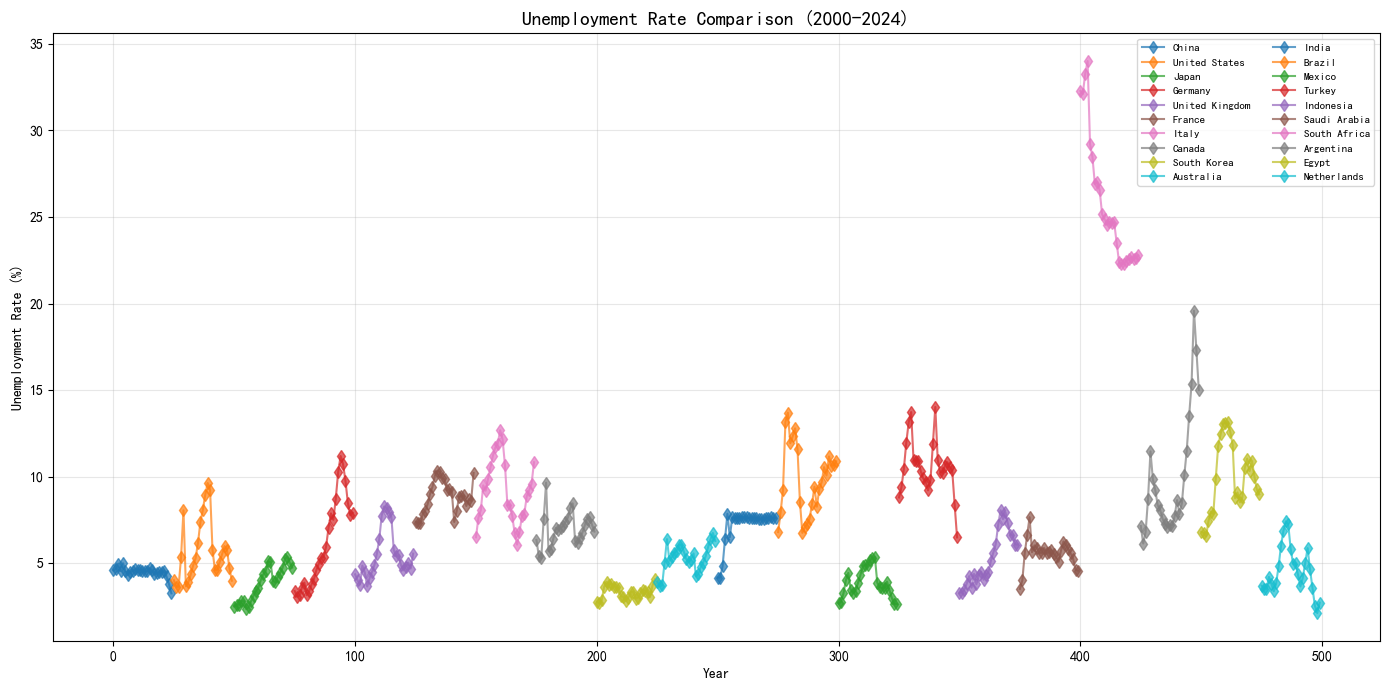

✅ Unemployment chart saved


In [14]:
# ===== 通胀率趋势图 =====
plt.figure(figsize=(14, 7))

for country in all_countries:
    country_data = data_clean[data_clean['country'] == country]
    if not country_data.empty:
        inflation_series = country_data['Inflation (%)'].dropna()
        if not inflation_series.empty:
            plt.plot(inflation_series.index, inflation_series.values, 
                    marker='s', linewidth=1.5, alpha=0.7, label=country)

plt.title('Inflation Rate Comparison (2000-2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Inflation (%)')
plt.legend(loc='best', ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('inflation_comparison.png', dpi=150)
plt.show()
print("✅ Inflation chart saved")

# ===== 失业率趋势图 =====
plt.figure(figsize=(14, 7))

for country in all_countries:
    country_data = data_clean[data_clean['country'] == country]
    if not country_data.empty:
        unemployment_series = country_data['Unemployment Rate (%)'].dropna()
        if not unemployment_series.empty:
            plt.plot(unemployment_series.index, unemployment_series.values, 
                    marker='d', linewidth=1.5, alpha=0.7, label=country)

plt.title('Unemployment Rate Comparison (2000-2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')
plt.legend(loc='best', ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('unemployment_comparison.png', dpi=150)
plt.show()
print("✅ Unemployment chart saved")